
* Undersampling => diminui a quantidade de registros

há dois dados e padronizam na mesma quantidade de tamanhos. Registros na classe azul e na classe laranja;

O ruim desta parte de analise é diminuindo, pode perder dados.


* Oversampling => Aumenta, faz copias das classes menores, aumentando a primeira tabela. 

Algoritmos de cálculos de similaridades para copiar os valores, ao invés de somente copiar.

Amostras sintéticas: escolhe as amostras dos dados, aumenta ou diminui próximos do registro. 


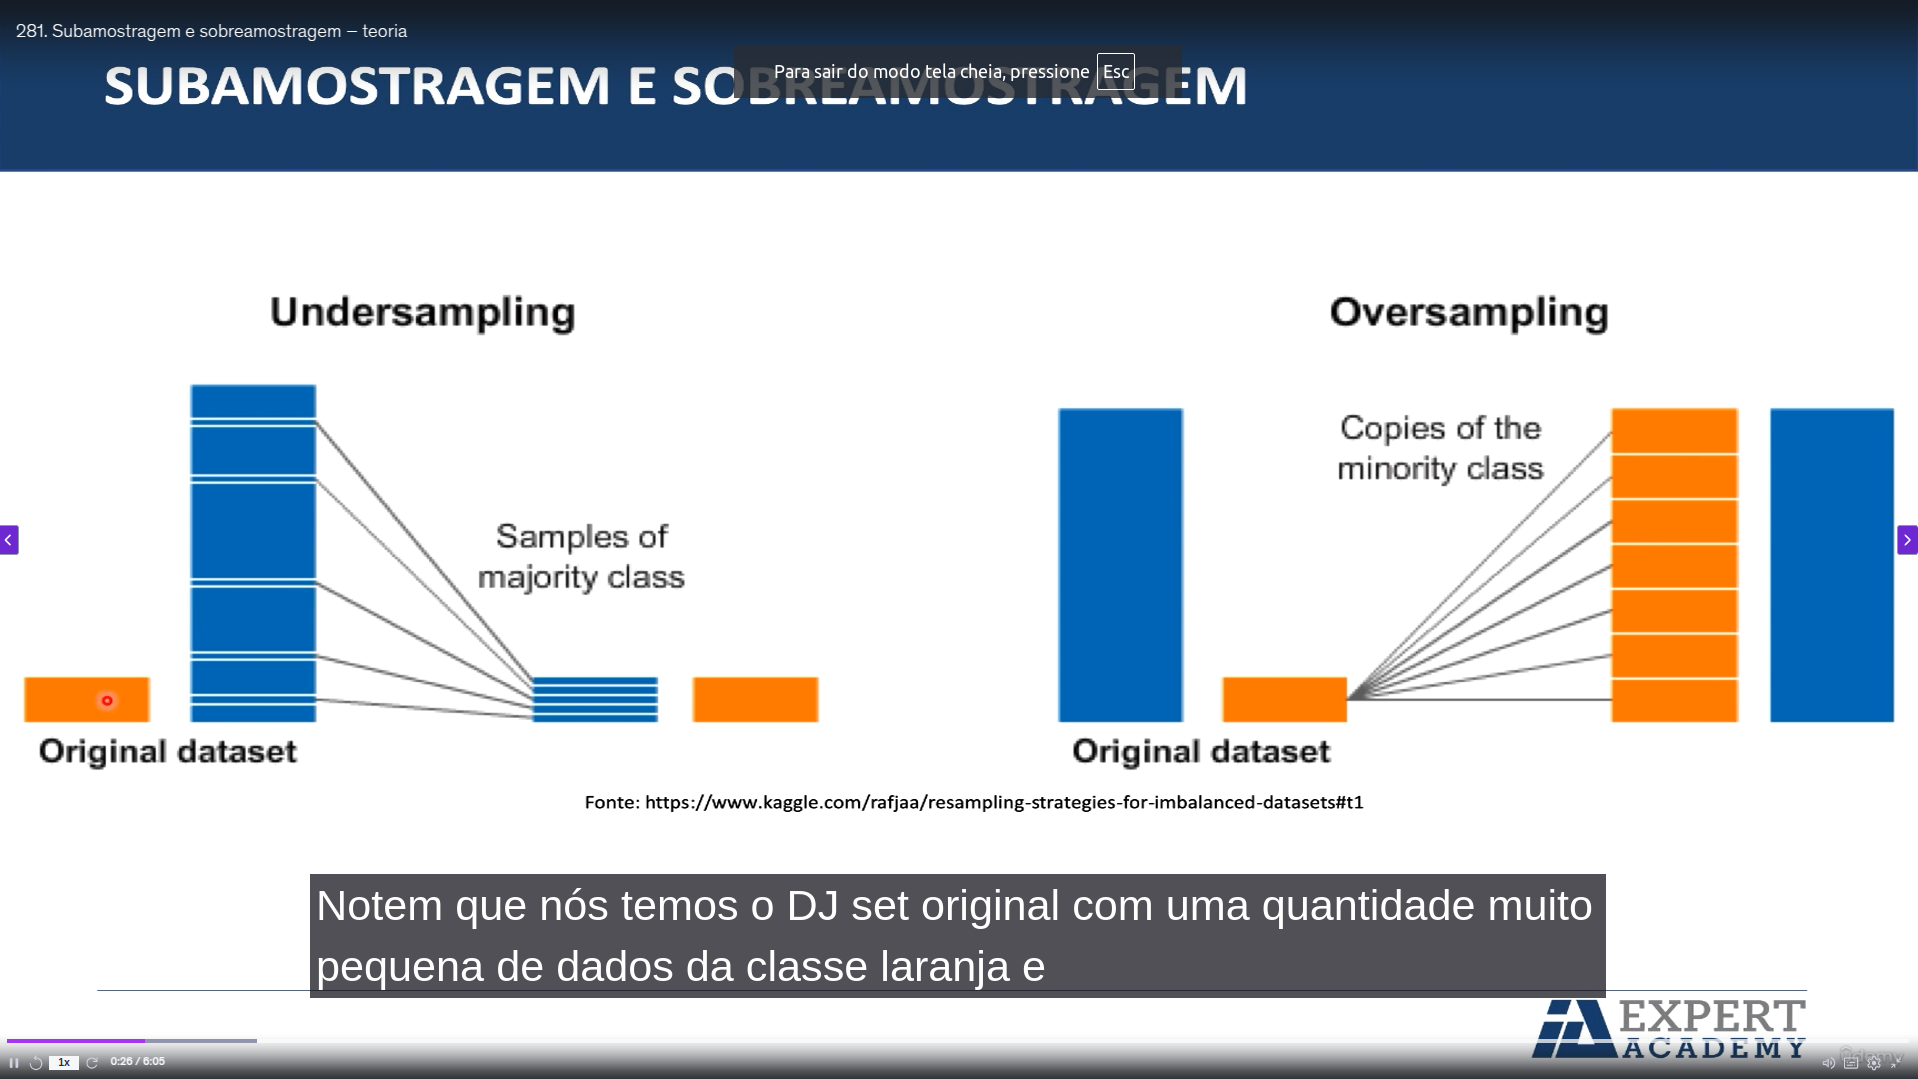

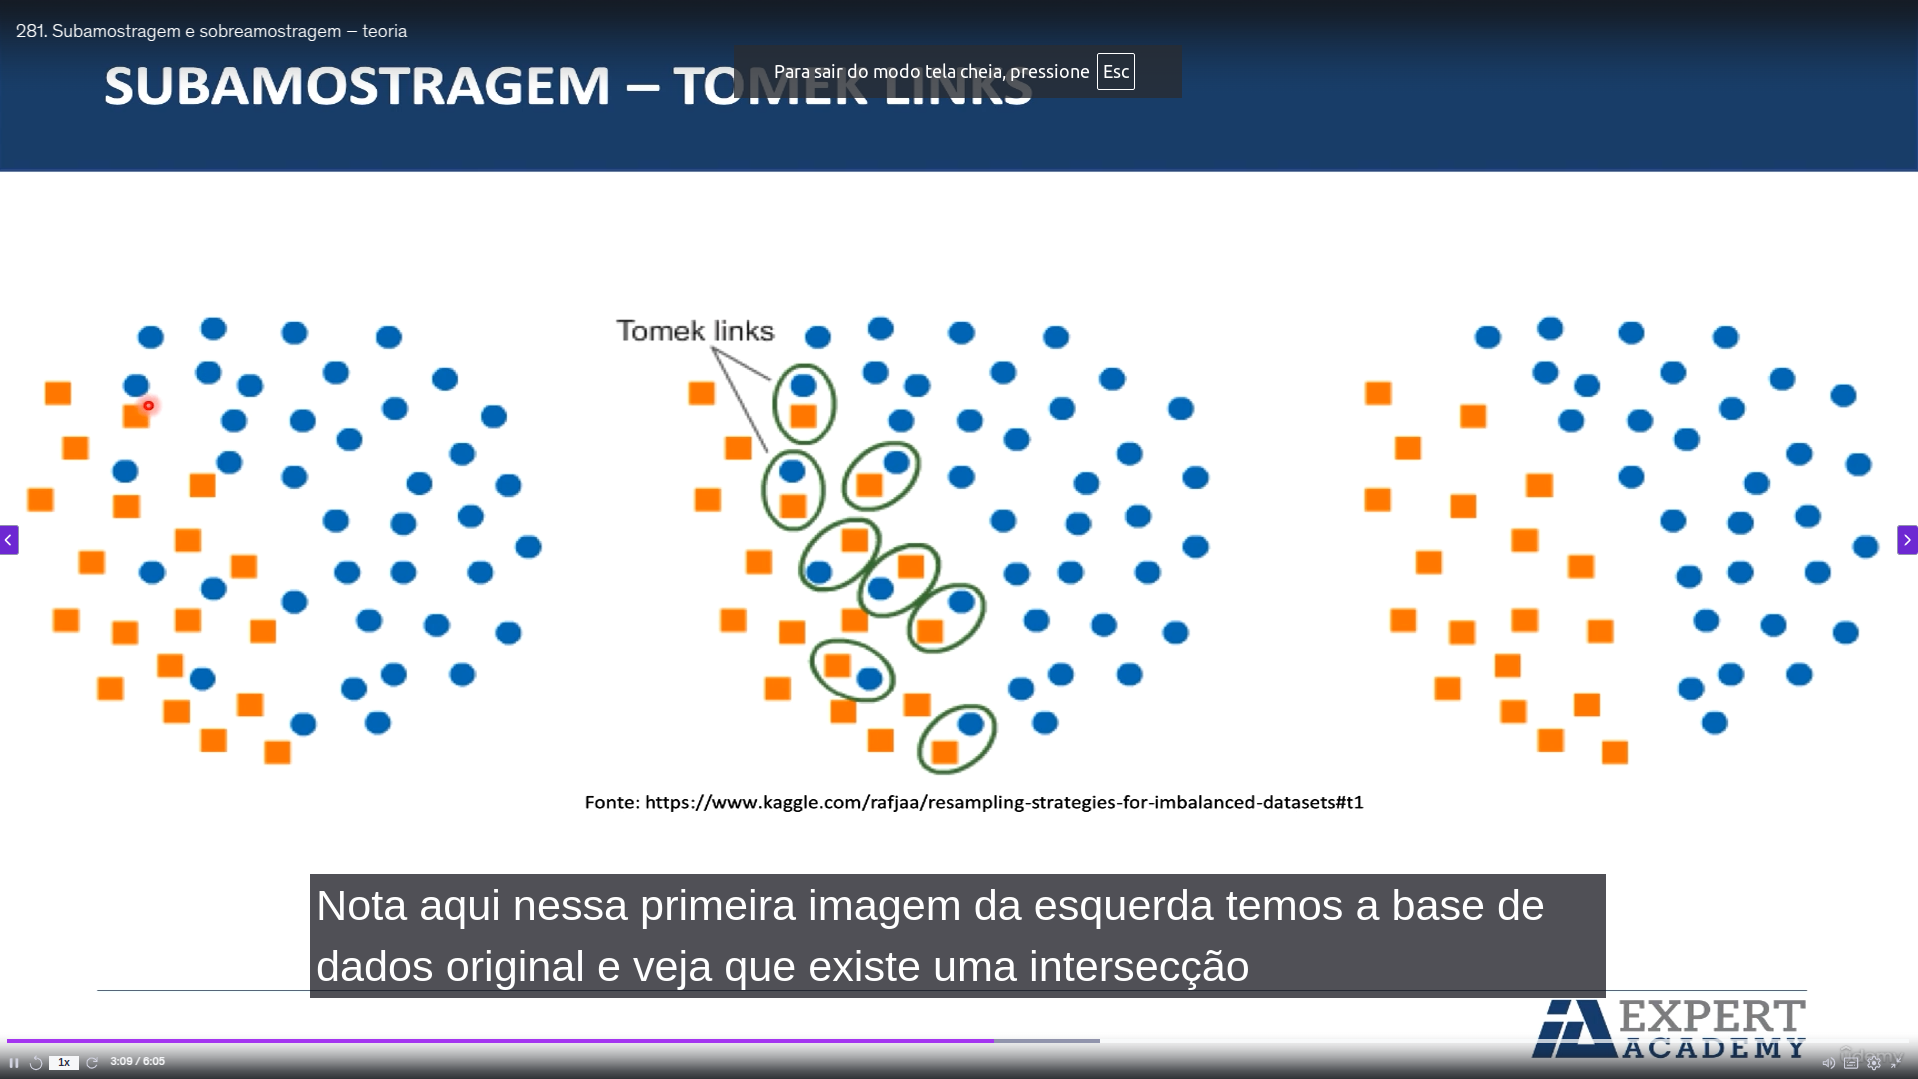


Apaga os registros azuis no meio, quando está muito próximo do laranja.

Construir a superfície separável. Retirar alguns registros que podem atrapalhar o processo. 


https://www.kaggle.com/code/rafjaa/resampling-strategies-for-imbalanced-datasets

sobreamostragem: deixar o registro na base minoritária


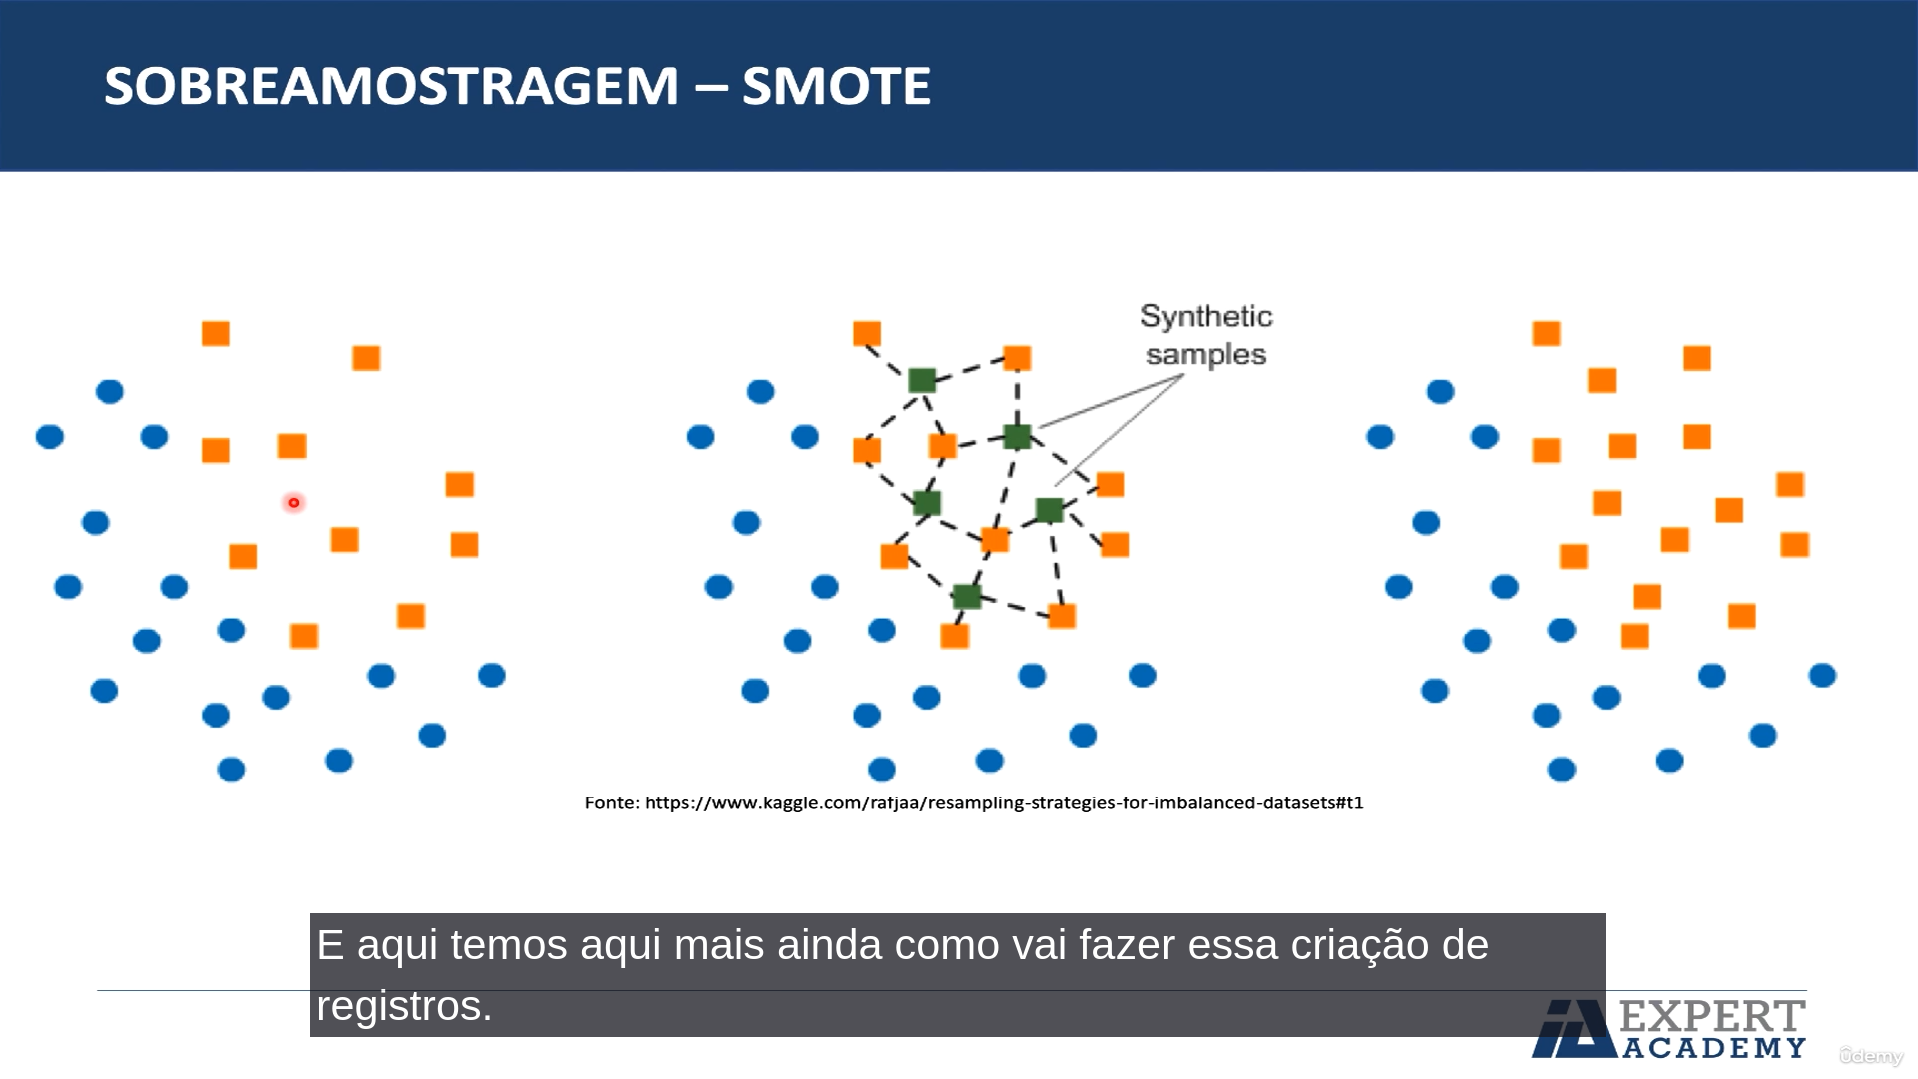

Preenche os espaços vazios, fazendo registros de dados sintéticos. => Sobreamostragem



In [1]:
# conda Udemy

In [68]:
import pandas as pd
import numpy as np
print(pd.__version__)
print(np.__version__) # abtes estava 1.26.4, atualizado para 2.3.4
base_census = pd.read_csv('census.csv')
base_census.tail()

2.3.3
2.3.4


,age,workclass,final-weight,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loos,hour-per-week,native-country,income
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K
32560,52,Self-emp-inc,287927,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K


In [69]:
print(f' colunas para a base de previsão : {list(base_census.columns[0:14])}')

 colunas para a base de previsão : ['age', 'workclass', 'final-weight', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loos', 'hour-per-week', 'native-country']


In [70]:
np.unique(base_census['income'], return_counts = True)

(array([' <=50K', ' >50K'], dtype=object), array([24720,  7841]))

In [71]:
# Remove 'id' and 'target' columns
labels = base_census.columns[0:14]

In [72]:
target = 'income'

In [73]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score



In [74]:
from sklearn.preprocessing import LabelEncoder
label_encoder_workclass = LabelEncoder()
label_encoder_education = LabelEncoder()
label_encoder_marital = LabelEncoder()
label_encoder_occupation = LabelEncoder()
label_encoder_relationship = LabelEncoder()
label_encoder_race = LabelEncoder()
label_encoder_sex = LabelEncoder()
label_encoder_country = LabelEncoder()



In [75]:
base_census['workclass'] = label_encoder_workclass.fit_transform(base_census['workclass'])


In [76]:
base_census['education'] = label_encoder_education.fit_transform(base_census['education'])


In [77]:
base_census['marital-status'] = label_encoder_marital.fit_transform(base_census['marital-status'])


In [78]:
base_census['occupation'] = label_encoder_occupation.fit_transform(base_census['occupation'])

In [79]:
base_census['relationship'] = label_encoder_relationship.fit_transform(base_census['relationship'])


In [80]:
base_census['race'] = label_encoder_race.fit_transform(base_census['race'])


In [81]:
base_census['sex'] = label_encoder_sex.fit_transform(base_census['sex'])


In [82]:
base_census['native-country'] = label_encoder_country.fit_transform(base_census['native-country'])

base_census['income'] = label_encoder_country.fit_transform(base_census['income'])

# -----------------------------------------------------------

Class 0 <=50K: 24720
Class 1 >50K: 7841
Proportion: 3.15 : 1


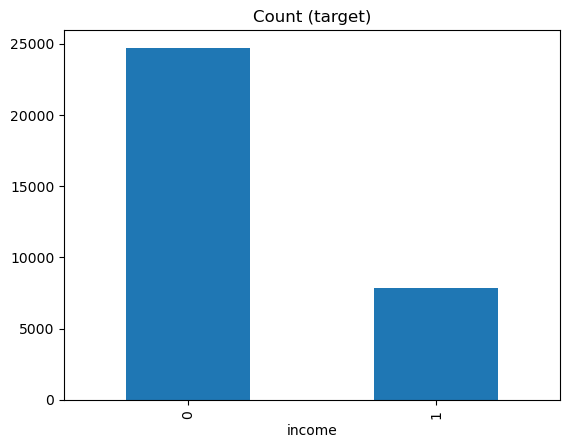

In [88]:
target_count = base_census.income.value_counts()
print('Class 0 <=50K:', target_count[0])
print('Class 1 >50K:', target_count[1])
print('Proportion:', round(target_count[0] / target_count[1], 2), ': 1')

target_count.plot(kind='bar', title='Count (target)');  #(array([' <=50K':0, ' >50K':1 ], dtype=object), array([24720,  7841]))


In [84]:
# Remove 'id' and 'target' columns

X = base_census[labels]
y = base_census[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

The metric trap

One of the major issues that novice users fall into when dealing with unbalanced datasets relates to the metrics used to evaluate their model. Using simpler metrics like accuracy_score can be misleading. In a dataset with highly unbalanced classes, if the classifier always "predicts" the most common class without performing any analysis of the features, it will still have a high accuracy rate, obviously illusory.

Let's do this experiment, using simple cross-validation and no feature engineering:

In [85]:
model = XGBClassifier()
model.fit(X_train, y_train)



,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [86]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: %.2f%%" % (accuracy * 100.0))

Accuracy: 86.69%


## Confusion matrix


An interesting way to evaluate the results is by means of a confusion matrix, which shows the correct and incorrect predictions for each class. In the first row, the first column indicates how many classes 0 were predicted correctly, and the second column, how many classes 0 were predicted as 1. In the second row, we note that all class 1 entries were erroneously predicted as class 0.

Therefore, the higher the diagonal values of the confusion matrix the better, indicating many correct predictions.

Confusion matrix:
 [[4657  369]
 [ 498  989]]


/tmp/ipykernel_15524/2092946711.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + labels)
/tmp/ipykernel_15524/2092946711.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + labels)


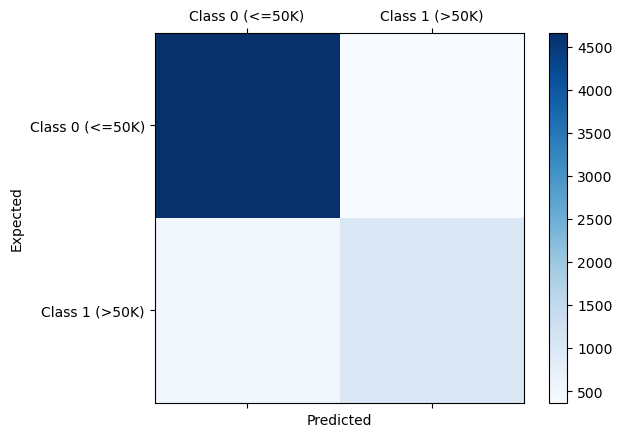

In [90]:
from sklearn.metrics import confusion_matrix
from matplotlib import pyplot as plt

conf_mat = confusion_matrix(y_true=y_test, y_pred=y_pred)
print('Confusion matrix:\n', conf_mat)

labels = ['Class 0 (<=50K)', 'Class 1 (>50K)']
fig = plt.figure()
ax = fig.add_subplot(111)
cax = ax.matshow(conf_mat, cmap=plt.cm.Blues)
fig.colorbar(cax)
ax.set_xticklabels([''] + labels)
ax.set_yticklabels([''] + labels)
plt.xlabel('Predicted')
plt.ylabel('Expected')
plt.show()

Confusion matrix:
 [[4657  369]
 [ 498  989]]


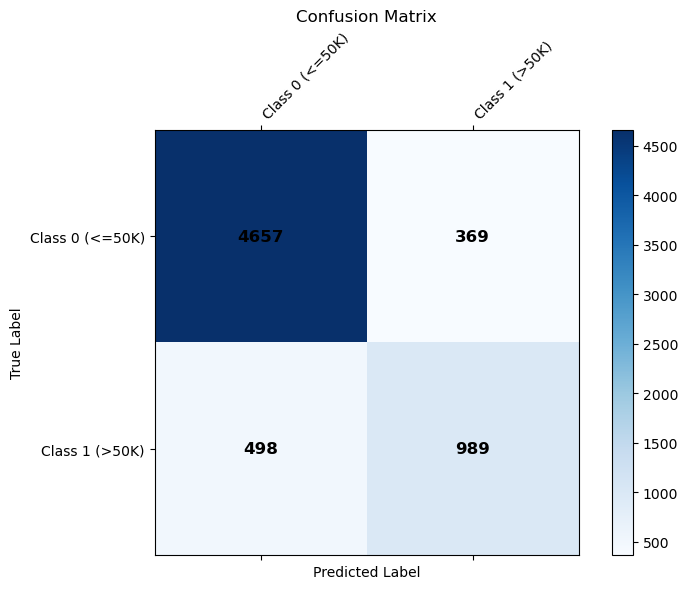

In [92]:
from sklearn.metrics import confusion_matrix
from matplotlib import pyplot as plt

print('Confusion matrix:\n', conf_mat)

# Definição dos Rótulos
labels = ['Class 0 (<=50K)', 'Class 1 (>50K)']
num_classes = len(labels)

fig = plt.figure(figsize=(8, 6)) # Define um tamanho razoável
ax = fig.add_subplot(111)


cax = ax.matshow(conf_mat, cmap=plt.cm.Blues)
fig.colorbar(cax)

#  CORREÇÃO PRINCIPAL: localizações das marcas (ticks)
# As posições devem ser 0 e 1 para uma matriz 2x2
tick_marks = np.arange(num_classes)
ax.set_xticks(tick_marks)
ax.set_yticks(tick_marks)

#  Aplique os rótulos (sem o primeiro elemento vazio desnecessário)
ax.set_xticklabels(labels, rotation=45, ha='left') # Rotação ajuda na leitura
ax.set_yticklabels(labels)

#  Adicionar os valores nas células (opcional, mas muito útil)
for i in range(num_classes):
    for j in range(num_classes):
        ax.text(j, i, conf_mat[i, j], 
                ha='center', 
                va='center', 
                color='black', 
                fontsize=12,
                fontweight='bold')

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

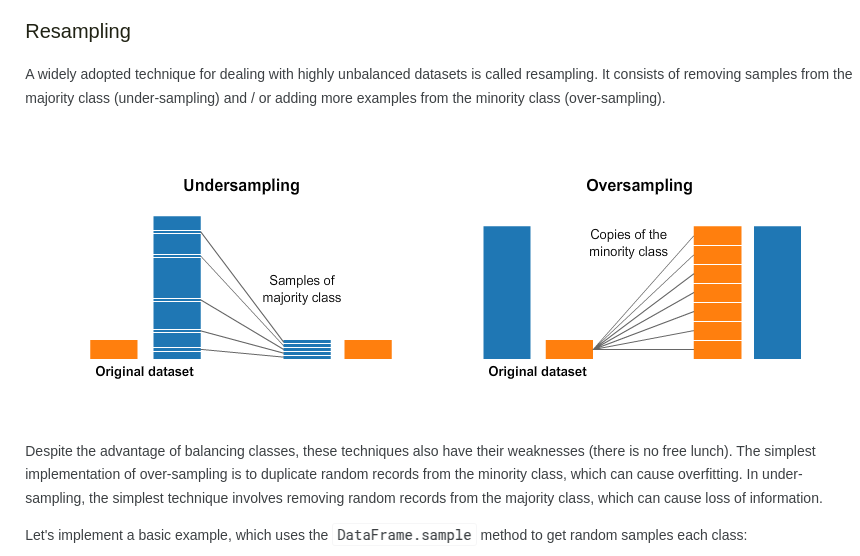

In [96]:
# Class count
count_class_0, count_class_1 = base_census.income.value_counts()

# Divide by class
df_class_0 = base_census[base_census[target] == 0]
df_class_1 = base_census[base_census[target] == 1]

## Random under-sampling


Random under-sampling:
income
0    7841
1    7841
Name: count, dtype: int64


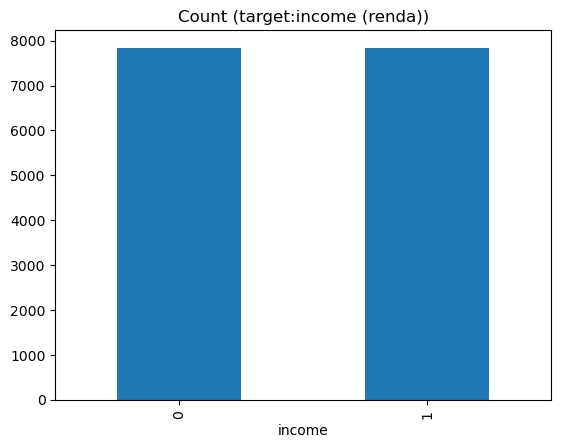

In [98]:
df_class_0_under = df_class_0.sample(count_class_1)
df_test_under = pd.concat([df_class_0_under, df_class_1], axis=0)

print('Random under-sampling:')
print(df_test_under.income.value_counts())

df_test_under.income.value_counts().plot(kind='bar', title='Count (target:income (renda))');

## Random over-sampling


Random over-sampling:
income
0    24720
1    24720
Name: count, dtype: int64


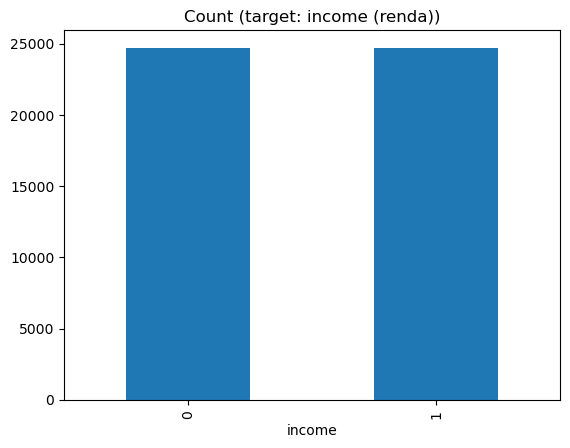

In [99]:
df_class_1_over = df_class_1.sample(count_class_0, replace=True)
df_test_over = pd.concat([df_class_0, df_class_1_over], axis=0)

print('Random over-sampling:')
print(df_test_over.income.value_counts())

df_test_over.income.value_counts().plot(kind='bar', title='Count (target: income (renda))');

Python imbalanced-learn module

A number of more sophisticated resapling techniques have been proposed in the scientific literature.

For example, we can cluster the records of the majority class, and do the under-sampling by removing records from each cluster, thus seeking to preserve information. In over-sampling, instead of creating exact copies of the minority class records, we can introduce small variations into those copies, creating more diverse synthetic samples.

Let's apply some of these resampling techniques, using the Python library imbalanced-learn. It is compatible with scikit-learn and is part of scikit-learn-contrib projects.

In [100]:
import imblearn


For ease of visualization, let's create a small unbalanced sample dataset using the make_classification method:



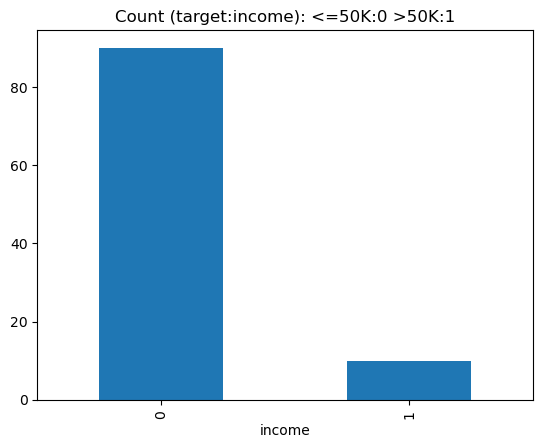

In [117]:
from sklearn.datasets import make_classification

X, y = make_classification(
    n_classes=2, class_sep=1.5, weights=[0.9, 0.1],
    n_informative=3, n_redundant=1, flip_y=0,
    n_features=20, n_clusters_per_class=1,
    n_samples=100, random_state=10
)

df = pd.DataFrame(X)
df['income'] = y
df.income.value_counts().plot(kind='bar', title='Count (target:income): <=50K:0 >50K:1');

Because the dataset has many dimensions (features) and our graphs will be 2D, we will reduce the size of the dataset using Principal Component Analysis (PCA):



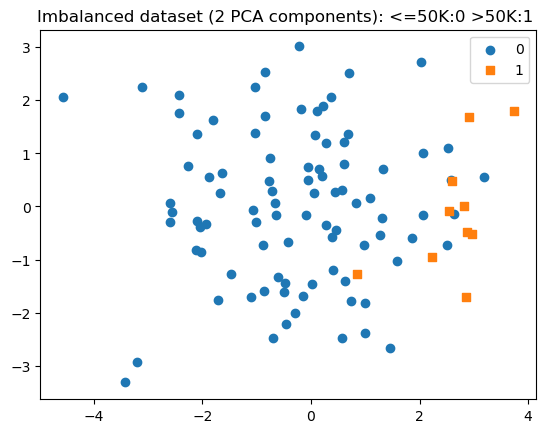

In [115]:
#We will also create a 2-dimensional plot function, plot_2d_space, to see the data distribution:


def plot_2d_space(X, y, label='Classes'):   
    colors = ['#1F77B4', '#FF7F0E']
    markers = ['o', 's']
    for l, c, m in zip(np.unique(y), colors, markers):
        plt.scatter(
            X[y==l, 0],
            X[y==l, 1],
            c=c, label=l, marker=m
        )
    plt.title(label)
    plt.legend(loc='upper right')
    plt.show()


from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X = pca.fit_transform(X)

plot_2d_space(X, y, 'Imbalanced dataset (2 PCA components): <=50K:0 >50K:1 ')

## Random under-sampling and over-sampling with imbalanced-learn


In [109]:
from imblearn.under_sampling import RandomUnderSampler

# 1. Inicialização Correta: Remova 'return_indices'
rus = RandomUnderSampler() 
#rus = RandomUnderSampler(return_indices=True)
# 2. Aplicação: O método fit_resample agora retorna os dados e rótulos rebalanceados.
# Se precisar dos índices, use o método `fit_resample` e verifique a documentação para alternativas.



In [111]:
# Substitua fit_sample por fit_resample

X_rus, y_rus = rus.fit_resample(X, y)

print('X reamostrado:', X_rus.shape)
print('y reamostrado:', y_rus.shape)

# Remova a linha que tentava capturar id_rus
# plot_2d_space(X_rus, y_rus, 'Random under-sampling')

X reamostrado: (20, 2)
y reamostrado: (20,)


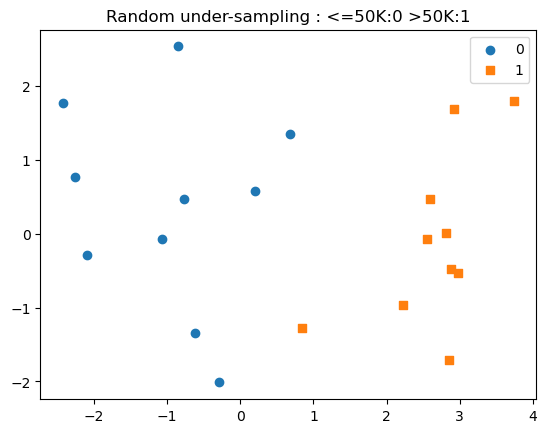

In [116]:

#X_rus, y_rus, id_rus = rus.fit_sample(X, y)

#print('Removed indexes:', id_rus)

plot_2d_space(X_rus, y_rus, 'Random under-sampling : <=50K:0 >50K:1')

80 new random picked points


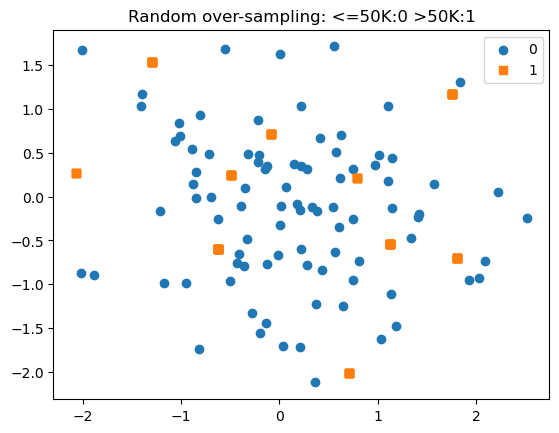

In [120]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler()
X_ros, y_ros = ros.fit_resample(X, y)

print(X_ros.shape[0] - X.shape[0], 'new random picked points')

plot_2d_space(X_ros, y_ros, 'Random over-sampling: <=50K:0 >50K:1')

## Under-sampling: Tomek links


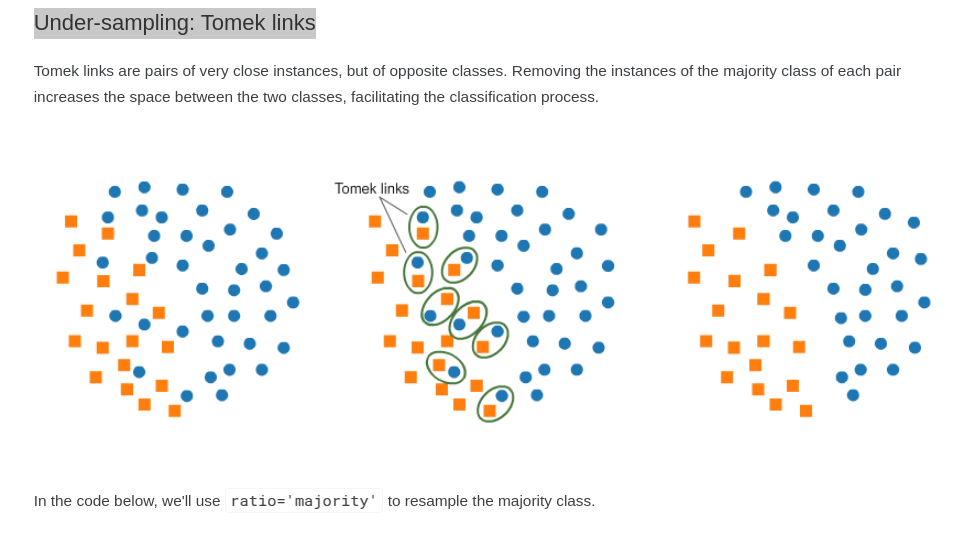

In [128]:
from imblearn.under_sampling import TomekLinks

# 1. Inicialize sem 'return_indices' e use 'sampling_strategy'
tl = TomekLinks(sampling_strategy='majority')

# 2. Use fit_resample e capture apenas X e y
X_tl, y_tl = tl.fit_resample(X, y)

# 3. Não é possível mais imprimir 'id_tl' diretamente com esta função
# print('Removed indexes:', id_tl) 

print('Tomek Links aplicados com sucesso.')
print('X reamostrado (após remoção):', X_tl.shape)
print('y reamostrado (após remoção):', y_tl.shape)

Tomek Links aplicados com sucesso.
X reamostrado (após remoção): (99, 20)
y reamostrado (após remoção): (99,)


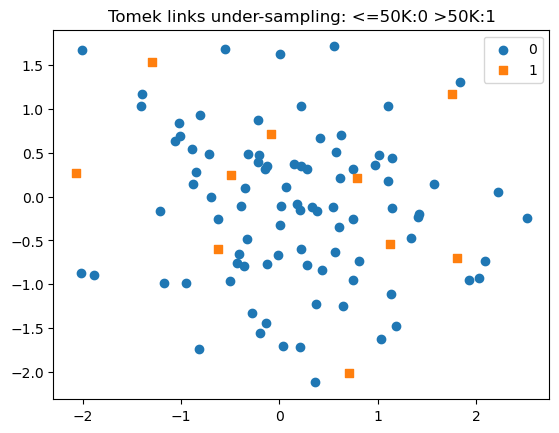

In [130]:
plot_2d_space(X_tl, y_tl, 'Tomek links under-sampling: <=50K:0 >50K:1')

### Under-sampling: Cluster Centroids

This technique performs under-sampling by generating centroids based on clustering methods. The data will be previously grouped by similarity, in order to preserve information.

In this example we will pass the {0: 10} dict for the parameter ratio, to preserve 10 elements from the majority class (0), and all minority class (1) .

In [132]:
from imblearn.under_sampling import ClusterCentroids

# 1. Inicialização CORRETA:
# Substitua 'ratio' por 'sampling_strategy'.
# Mantenha o dicionário para definir o número exato de amostras da classe majoritária (0).
# O valor '10' significa que a classe 0 será subamostrada para ter 10 instâncias.
cc = ClusterCentroids(sampling_strategy={0: 10}) 

# 2. Aplicação CORRETA:
# Substitua fit_sample() por fit_resample().
X_cc, y_cc = cc.fit_resample(X, y)

print('Cluster Centroids aplicados com sucesso.')
print('X reamostrado:', X_cc.shape)
print('y reamostrado:', y_cc.shape)



Cluster Centroids aplicados com sucesso.
X reamostrado: (20, 20)
y reamostrado: (20,)


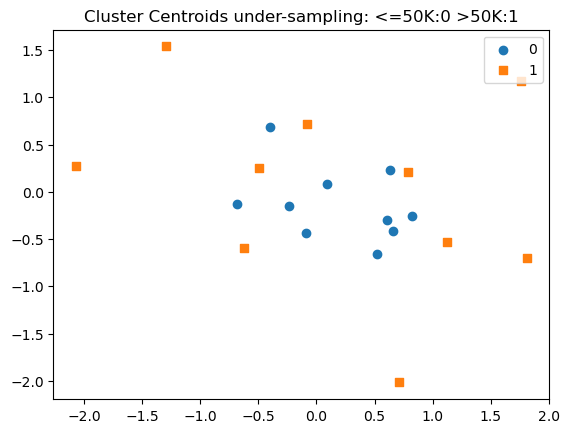

In [133]:
plot_2d_space(X_cc, y_cc, 'Cluster Centroids under-sampling: <=50K:0 >50K:1')

## Over-sampling: SMOTE


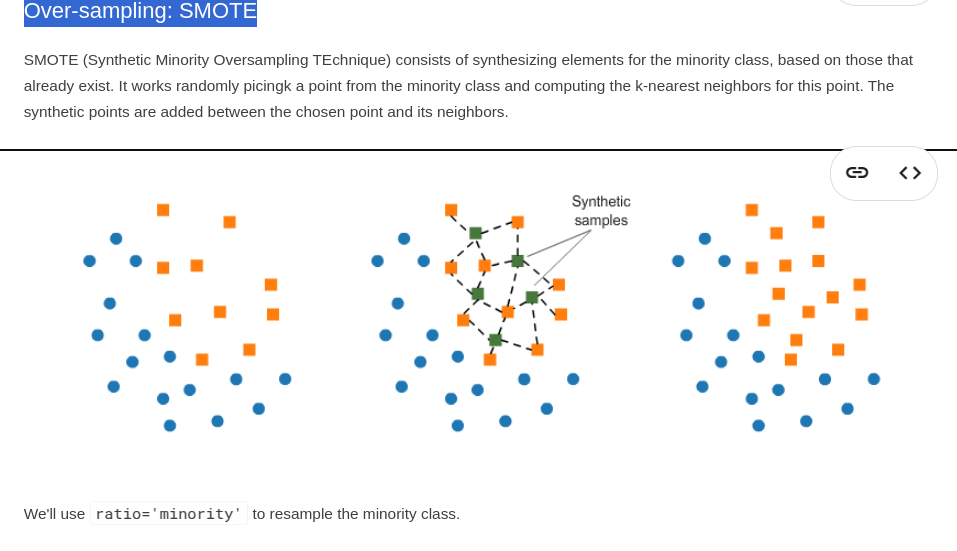

SMOTE aplicado com sucesso.
X reamostrado: (180, 20)
y reamostrado: (180,)


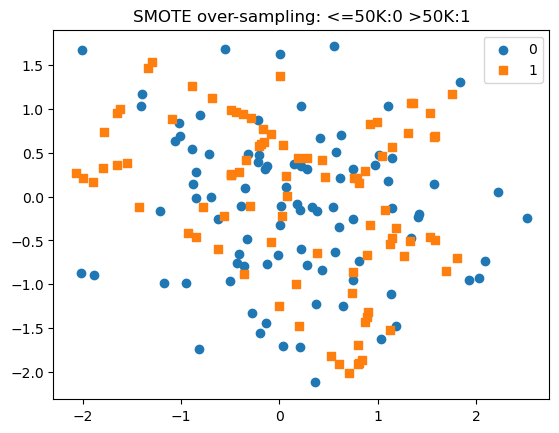

In [136]:
from imblearn.over_sampling import SMOTE

# smote = SMOTE(ratio='minority')
# X_sm, y_sm = smote.fit_sample(X, y)
from imblearn.over_sampling import SMOTE

# 1. Inicialização CORRETA:
# Substitua 'ratio' por 'sampling_strategy'.
# O valor 'minority' significa que a classe minoritária será superamostrada 
# até que todas as classes tenham o mesmo número de instâncias (equilíbrio).
smote = SMOTE(sampling_strategy='minority') 

# 2. Aplicação CORRETA:
# Substitua fit_sample() por fit_resample().
X_sm, y_sm = smote.fit_resample(X, y)

print('SMOTE aplicado com sucesso.')
print('X reamostrado:', X_sm.shape)
print('y reamostrado:', y_sm.shape)

plot_2d_space(X_sm, y_sm, 'SMOTE over-sampling: <=50K:0 >50K:1')

## Over-sampling followed by under-sampling

Now, we will do a combination of over-sampling and under-sampling, using the SMOTE and Tomek links techniques:

SMOTETomek aplicado com sucesso.
X reamostrado: (180, 20)
y reamostrado: (180,)


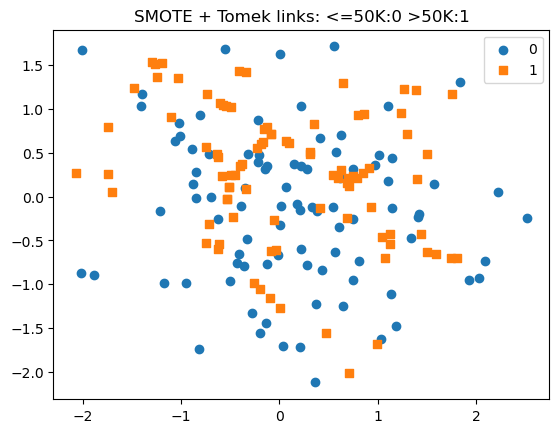

In [139]:
from imblearn.combine import SMOTETomek

# 1. Inicialização CORRETA:
# Substitua 'ratio' por 'sampling_strategy'.
# O valor 'auto' é inválido para sampling_strategy. 
# O SMOTETomek, que é uma combinação, geralmente requer 'minority' ou 'auto' (que no novo nome é 'auto' ou 'not majority').
# Para balanceamento padrão, 'auto' pode ser substituído por 'minority' ou 'not majority'.

# Use 'auto' se o seu objetivo for o comportamento padrão (similar ao antigo 'auto')
# Nota: o comportamento mais comum para combinação é 'auto' ou 'not majority'.
# Vamos usar o padrão implícito, que é 'auto', mas é melhor usar 'sampling_strategy' = 'auto'
smt = SMOTETomek(sampling_strategy='auto') 

# 2. Aplicação:
X_smt, y_smt = smt.fit_resample(X, y)

print('SMOTETomek aplicado com sucesso.')
print('X reamostrado:', X_smt.shape)
print('y reamostrado:', y_smt.shape)

plot_2d_space(X_smt, y_smt, 'SMOTE + Tomek links: <=50K:0 >50K:1')